In [75]:
import copy
from pathlib import Path
from pprint import pprint

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
# %matplotlib widget

from scipy.interpolate import interp1d
import scipy
print(scipy.__version__)

import spectra.data as data
from spectra.resin import ResinConstituentAbsorber, ResinConstituentMonomer, Resin
from spectra.irradiance import Irradiance
from spectra.utilities import ArrayParams, find_index_of_nearest, find_index_of_max
from spectra.normalizeddose import NormalizedDose
from spectra.sourcespectrum import SourceSpectrum

1.4.1


# Common variables

In [2]:
wavelengths = np.linspace(*ArrayParams(300, 440, 281))

# Absorbers

## Create resins

In [3]:
pegda = ResinConstituentMonomer(data.monomers['PEGDA'], 100)
avobenzone = ResinConstituentAbsorber(
    data.absorbers['avobenzone_in_PEGDA_2017-04-13'],
    2.0
)

nps = ResinConstituentAbsorber(
    data.absorbers['nps_in_PEGDA_2017-04-13'],
    2.0
)

irgacure819 = ResinConstituentAbsorber(
    data.photoinitiators['irgacure819_in_PEGDA_2017-04-13'],
    1.0
)

resin = Resin(monomers=pegda, absorbers=[avobenzone,nps], photoinitiators=irgacure819)
resin_nps = Resin(monomers=pegda, absorbers=nps)
resin_avo = Resin(monomers=pegda, absorbers=avobenzone)


## Plot absorber spectra

(0.0, 0.7)

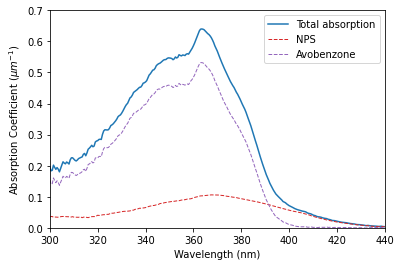

In [7]:
fig, ax = plt.subplots()
ax.plot(wavelengths, resin.calc_absorption_coef_inv_um(wavelengths), label='Total absorption')
ax.plot(wavelengths, resin_nps.calc_absorption_coef_inv_um(wavelengths), c='C3', lw=1, ls='--', label='NPS')
ax.plot(wavelengths, resin_avo.calc_absorption_coef_inv_um(wavelengths), c='C4', lw=1, ls='--', label='Avobenzone')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Absorption Coefficient (${\mu m}^{-1}$)')
ax.legend(loc='upper right')
ax.set_xlim(300,440)
ax.set_ylim(0, 0.7)
# ax.grid()


# Sources

In [9]:
data.sources

{'365nm_visitech_with_50mm_asahi_filter_2018-11-22': <spectra.sourcespectrum.SourceSpectrum at 0x7f976199ae10>,
 'Asiga_405nm_100um_fiber-2016-12-14': <spectra.sourcespectrum.SourceSpectrum at 0x7f97615d2d10>,
 'HR1_385nm_100um_fiber-2016-12-14': <spectra.sourcespectrum.SourceSpectrum at 0x7f976199ad10>,
 'HR2_385nm_2020-03-23': <spectra.sourcespectrum.SourceSpectrum at 0x7f976199a8d0>,
 'HR3.2_365nm_370nm_short_pass_filter-2019-12-31': <spectra.sourcespectrum.SourceSpectrum at 0x7f97611313d0>,
 'HR3.2_365nm_no_filter-2019-12-31': <spectra.sourcespectrum.SourceSpectrum at 0x7f976199a590>,
 'HR3.3_365nm_370nm_short_pass_filter-2020-03-23': <spectra.sourcespectrum.SourceSpectrum at 0x7f976199a890>,
 'HR3.3_365nm_no_filter-2020-03-23': <spectra.sourcespectrum.SourceSpectrum at 0x7f976199ab90>,
 'HR3.3_365nm_through_tray_370nm_short_pass_filter-2020-03-23': <spectra.sourcespectrum.SourceSpectrum at 0x7f9761989390>,
 'HR3.3_365nm_through_tray_no_filter-2020-03-23': <spectra.sourcespectrum.S

## 365 nm with and without short pass filter

In [11]:
source_365nm = data.sources['HR3.2_365nm_no_filter-2019-12-31']
source_365nm_shortpass = data.sources['HR3.2_365nm_370nm_short_pass_filter-2019-12-31']


## Construct a bandpass filter

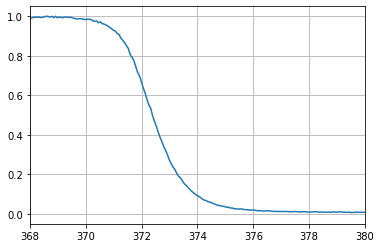

In [16]:
fig, ax = plt.subplots()
ax.plot(source_365nm_shortpass.wavelength, source_365nm_shortpass.power)
ax.set_xlim(368,380)
ax.grid()

In [24]:
asahi_measured_data = np.genfromtxt('370nm shortpass filter_original.csv', delimiter=',', skip_header=2)
# Convert from percent to fractional transmission
asahi_measured_data[:, 1] = asahi_measured_data[:, 1]/100.
# Normalize
asahi_measured_data[:, 1] = asahi_measured_data[:, 1]/np.max(asahi_measured_data[:, 1])

def asahi_measured_interp(w, left=1.0, right=0.0):
    return np.interp(w, asahi_measured_data[:,0], asahi_measured_data[:,1])


71
78


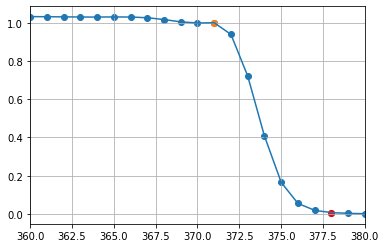

In [36]:
index_temp = find_index_of_nearest(asahi_measured_data[:,0], 371)
print(index_temp)
index_temp2 = find_index_of_nearest(asahi_measured_data[:,0], 378)
print(index_temp2)

fig, ax = plt.subplots()
ax.scatter(asahi_measured_data[:,0], asahi_measured_data[:,1])
ax.scatter(asahi_measured_data[index_temp,0], asahi_measured_data[index_temp,1])
ax.scatter(asahi_measured_data[index_temp2,0], asahi_measured_data[index_temp2,1], c='r')
ax.plot(source_365nm_shortpass.wavelength, asahi_measured_interp(source_365nm_shortpass.wavelength))
ax.set_xlim(360,380)
ax.grid()

In [33]:
# Normalize again
asahi_measured_data[:, 1] = asahi_measured_data[:, 1]/np.max(asahi_measured_data[index_temp, 1])


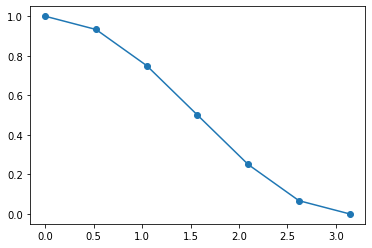

In [60]:
x_vals = np.linspace(0, np.pi, 7)
y_vals = (1 + np.cos(x_vals)) / 2.

fig, ax = plt.subplots()
ax.plot(x_vals, y_vals)
ax.scatter(x_vals, y_vals)

In [76]:
f_linear = interp1d(x_vals, y_vals, fill_value=(1,0), bounds_error=False)
f_cubic = interp1d(x_vals, y_vals, kind='cubic')

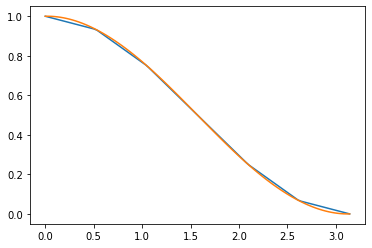

In [67]:
x_new = np.linspace(0, np.pi, 101)
y_new = (1 + np.cos(x_new)) / 2.


fig, ax = plt.subplots()
# ax.plot(x_new, y_new)
ax.plot(x_new, f_linear(x_new))
ax.plot(x_new, f_cubic(x_new))


In [69]:
for x, y in zip(x_new, y_new):
    print(x, y, f_linear(x), f_cubic(x))

0.0 1.0 1.0 1.0
0.031415926535897934 0.9997532801828658 0.9959807621135331 1.0000651070270803
0.06283185307179587 0.9990133642141358 0.9919615242270663 0.9995617626677239
0.0942477796076938 0.99778098230154 0.9879422863405994 0.9984995898963648
0.12566370614359174 0.996057350657239 0.9839230484541327 0.9968882116874387
0.15707963267948966 0.9938441702975689 0.9799038105676658 0.9947372510153799
0.1884955592153876 0.9911436253643444 0.975884572681199 0.9920563308546237
0.21991148575128555 0.9879583809693737 0.9718653347947321 0.9888550741796048
0.25132741228718347 0.9842915805643155 0.9678460969082653 0.9851431039647585
0.2827433388230814 0.9801468428384715 0.9638268590217984 0.9809300431845189
0.3141592653589793 0.9755282581475768 0.9598076211353317 0.9762255148133213
0.3455751918948773 0.9704403844771128 0.9557883832488648 0.9710391418256004
0.3769911184307752 0.9648882429441257 0.951769145362398 0.9653805471957912
0.4084070449666731 0.9588773128419905 0.9477499074759311 0.95925935389

In [78]:
f_linear(-0.1)

array(1.)

In [79]:
try_interp1d = interp1d(asahi_measured_data[71:78+1,0], 
                        asahi_measured_data[71:78+1,1], 
                        kind='cubic', 
                        fill_value=(1.,0.),
                        bounds_error=False
                       )


In [80]:
try_interp1d([371, 372, 375, 378, 380])

array([1.        , 0.93890508, 0.16543623, 0.00675427, 0.        ])

In [81]:
try_interp1d([365., 371, 372, 375, 378, 380])

array([1.        , 1.        , 0.93890508, 0.16543623, 0.00675427,
       0.        ])

ValueError: A value in x_new is below the interpolation range.

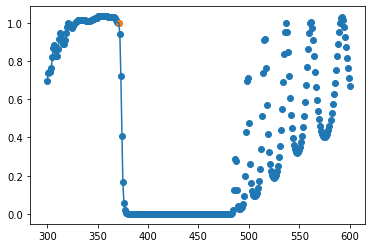

In [45]:
try_interp1d = interp1d(asahi_measured_data[71:78+1,0], asahi_measured_data[71:78+1,1], kind='cubic', fill_value=(1,0))

# wavelengths_temp = np.linspace(350, 400, 501)

fig, ax = plt.subplots()
ax.scatter(asahi_measured_data[:,0], asahi_measured_data[:,1])
ax.scatter(asahi_measured_data[index_temp,0], asahi_measured_data[index_temp,1])
ax.plot(source_365nm_shortpass.wavelength, asahi_measured_interp(source_365nm_shortpass.wavelength), label='raw data')
ax.plot(source_365nm_shortpass.wavelength, try_interp1d(source_365nm_shortpass.wavelength), label='cubic interpolation')
ax.set_xlim(360,380)
ax.legend()
ax.grid()

In [38]:
right_edge_wavelengths = asahi_measured_data[index_temp:index_temp2+1,0].copy()

right_edge_wavelengths

# def filter_right_edge(w, left=1.0, right=0.0):
#     return np.interp(w, asahi_measured_data[:,0], asahi_measured_data[:,1])


[371. 372. 373. 374. 375. 376. 377. 378.]


In [39]:
right_edge_filter = asahi_measured_data[index_temp:index_temp2+1, 1].copy()
right_edge_filter

array([1.        , 0.93890508, 0.72161036, 0.40772658, 0.16543623,
       0.05495517, 0.01830751, 0.00675427])

## 385 nm with and without bandpass filter